## Neural Networks

**Artificial neural networks**: neurons organized in layers (hidden), synapsis multiply wights to input and give to neuron.

**Forward Propagation** neuron use activation function to process input from synapsis, called activity, *z*.
After using the activation function a new activity is produced by the neuron (neuron output), which is a matrix same size of the first activity. 
**Back Propagation** computes the error of the final output and propagates it backward through the network layers using the chain rule of calculus. This process calculates the gradients of the loss function with respect to each synapse's weight, providing the necessary feedback for the optimizer to adjust them and minimize the error and produce new wights.

* **Hyperparameters**: layers, neuron per layer, learning rate, free parameters in the activation function, batch size, regularization parameters, optimizer, dropouts.

* **Cost function**: to evaluate the model performance, we're trying to minimize the offset between a model and some data. Can be a L2 or L1 cost function similar to Huber.\
Training a network means *minimizing a cost function*, by chainging wights of synapsis. [Dimensionality Curse: computational cost exp increase with number of weights to be decided]\
To solve dim curse, optimize weight using *Gradient Descend*. Important option: **learning rate** controls step dimension. It's fixed for all parameters.   
To avoid local minima, optimize weight using *Stochastic Gradient Descend*.
To have **adaptive learning rate** use ADAM.
Which cost to use dep on which algorithm. For regression: MSE. For classification: Logistic or Hinge (for VSM).


* **Activation function**: there are two types: 
1) Output layer: it's at the very last layer is dictated entirely by what you are trying to predict (can use logistic). The choice depend on the problem just like the loss function.
2) Hidden layer: don't dep on the problem, only has introduce non linearity in the feature and at same time to optimize the gradient descent (use ReLu).

* **Dropout** is the regularization. Causes some neurons to be temporarily "dropped out" during training (usually by setting some probability for that to happen, typically 10-50%).
* **Batch Normalization** normalize and standardize input (data) at each hidden layer. Is done before passing the data to the activation function. It make the process more stable and can also make it faster.
* **Data Augmentation** Transforming your data can result in a better fit; this is called data augmentation. For instance, instead of feeding $x$, you can feed $x^2$ and $x^3$. This is particularly powerful when training on images.


## Can a computer learn if we're going to detect gravitational waves?

In [3]:
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

path = "sample_2e7_design_precessing_higherordermodes_3detectors.h5"
with h5py.File(path, 'r') as f:
    fin = {key: f[key][()] for key in f.keys()}

N_lim = 500000
data = {k: v[:N_lim] for k, v in fin.items()}
df = pd.DataFrame(data)

#selezione features
y = df['det']
X = df.drop(columns=['snr', 'det'])

print(f"\nDataset creato, dimensioni X: {X.shape}")
print(f"Feature mantenute: {list(X.columns)}")


Dataset creato, dimensioni X: (500000, 13)
Feature mantenute: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z']


### Validation on both the number of Neurons and the Patch

In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, f1_score

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
# Proporzioni finali: 60% Train, 20% Val, 20% Test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

def build_mlp_model(hidden_units=64):         
    model = keras.Sequential([                                      
        layers.Input(shape=(X_train_scaled.shape[1],)),             
        layers.Dense(hidden_units, activation='relu'),              
        layers.Dense(hidden_units // 2, activation='relu'),         
        layers.Dense(1, activation='sigmoid')                       
    ])

    optimizer = keras.optimizers.Adam(learning_rate=0.005)  
    #la loss è la logistic
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

# Creazione dinamica della griglia di 9 configurazioni (3 neuroni x 3 batch size)
unit_options = [16,32,64]
batch_size_options = [256,128,64,32]
hyperparameters = [{'units': u, 'batch_size': b} for u in unit_options for b in batch_size_options]

best_auc = 0
best_model = None
best_params = None
histories = {} 

In [ ]:
print("Inizio Ottimizzazione Iperparametri")

for params in hyperparameters:
    units = params['units']
    bs = params['batch_size']
    config_name = f"{units}u_{bs}bs"
    
    print(f"\n[ Addestramento: {units} Neuroni | Batch Size {bs} ]")
    model = build_mlp_model(hidden_units=units)
    
    #CALLBACKS
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") + f"_{config_name}"
    tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
    #Early Stop: fermati se per 8 epoche la val_loss non scende
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    #LR Adattivo: Se la val_loss non scende per 3 epoche, moltiplica il LR per 0.2. Minimo LR = 1e-5
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)

    # Addestramento della rete
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,            
        batch_size=bs,               
        validation_data=(X_val_scaled, y_val),
        callbacks=[tensorboard_callback, early_stop, reduce_lr],
        verbose=0              
    )
    
    # Salviamo l'history associandola al config_name
    histories[config_name] = history.history
    epoche_effettive = len(history.history['loss'])

    y_val_pred_probs = model.predict(X_val_scaled, verbose=0)
    y_val_pred_binary = (y_val_pred_probs > 0.5).astype(int)
    
    val_auc = max(history.history['val_auc'])
    val_acc = accuracy_score(y_val, y_val_pred_binary)
    val_comp = recall_score(y_val, y_val_pred_binary)
    val_cont = 1 - precision_score(y_val, y_val_pred_binary, zero_division=0)
    
    print(f"-> Addestramento fermato all'epoca {epoche_effettive}.")
    val_auc = max(history.history['val_auc'])
    print(f"-> AUC massima sul Validation Set: {val_auc:.4f}")

    print(f"-> Val Accuracy:      {val_acc:.4f}")
    print(f"-> Val Completeness:  {val_comp:.4f}")
    print(f"-> Val Contamination: {val_cont:.4f}")

    
    if val_auc > best_auc:          #AUC è uno score adatta per classi sbilanciate, è threshold indipendente
        best_auc = val_auc
        best_model = model
        best_params = params


Inizio Ottimizzazione Iperparametri

[ Addestramento: 16 Neuroni | Batch Size 256 ]

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001999999862164259.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.9999996079131965e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 1e-05.
-> Addestramento fermato all'epoca 64.
-> AUC massima sul Validation Set: 0.9968
-> Val Accuracy:      0.9799
-> Val Completeness:  0.9308
-> Val Contamination: 0.0693

[ Addestramento: 16 Neuroni | Batch Size 128 ]

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001999999862164259.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.9999996079131965e-05.

Epoch 32: ReduceLROnPlateau reducing learning rate to 1e-05.
-> Addestramento fermato all'epoca 40.
-> AUC massima sul Validation Set: 0.9971
-> Val Accuracy:      0.9

In [6]:
print (best_params)
print(f"*** ADDESTRAMENTO MODELLO FINALE SULL'80% DEI DATI ***")

scaler_finale = StandardScaler()
X_temp_scaled = scaler_finale.fit_transform(X_temp) #train + val
X_test_scaled = scaler_finale.transform(X_test)

final_units = best_params['units']
final_bs = best_params['batch_size']

final_model = build_mlp_model(hidden_units=final_units)
early_stop_final = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr_final = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)

final_history = final_model.fit(
    X_temp_scaled, y_temp,
    epochs=100,
    batch_size=final_bs,
    validation_data=(X_test_scaled, y_test), # Usiamo il Test Set per monitorare l'andamento
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1 # Messo a 1 così vedi l'avanzamento dal vivo
)

epoche_finali = len(final_history.history['loss'])
print(f"\n-> Addestramento finale concluso in {epoche_finali} epoche.")

{'units': 64, 'batch_size': 256}
*** ADDESTRAMENTO MODELLO FINALE SULL'80% DEI DATI ***
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 936us/step - accuracy: 0.9625 - auc: 0.9907 - loss: 0.0859 - precision: 0.8774 - val_accuracy: 0.9718 - val_auc: 0.9947 - val_loss: 0.0648 - val_precision: 0.9019 - learning_rate: 0.0050
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - accuracy: 0.9756 - auc: 0.9960 - loss: 0.0562 - precision: 0.9149 - val_accuracy: 0.9759 - val_auc: 0.9960 - val_loss: 0.0561 - val_precision: 0.9020 - learning_rate: 0.0050
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 535us/step - accuracy: 0.9784 - auc: 0.9967 - loss: 0.0502 - precision: 0.9241 - val_accuracy: 0.9768 - val_auc: 0.9967 - val_loss: 0.0541 - val_precision: 0.8974 - learning_rate: 0.0050
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.9795 - auc: 0.9971 - loss: 0.0475 - precision: 0.9277 - val_accuracy: 0.9783 - val_auc: 0.9966 - val_loss: 0.0502 - val_precision: 0.9311 - le

In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

print(f"*** MIGLIORI IPERPARAMETRI: {best_params} ***")
print(f"*** AUC SUL VALIDATION SET: {best_auc:.4f} ***")
# Calcolo previsioni per il modello migliore
y_pred_probs_best = best_model.predict(X_val_scaled)

# Dati ROC
fpr, tpr, roc_thresholds = roc_curve(y_val, y_pred_probs_best)
roc_auc = auc(fpr, tpr)

# Dati Completeness e Contamination
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_probs_best)
completeness = recall
contamination = 1 - precision

*** MIGLIORI IPERPARAMETRI: {'units': 64, 'batch_size': 256} ***
*** AUC SUL VALIDATION SET: 0.9984 ***
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 156us/step


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 147us/step


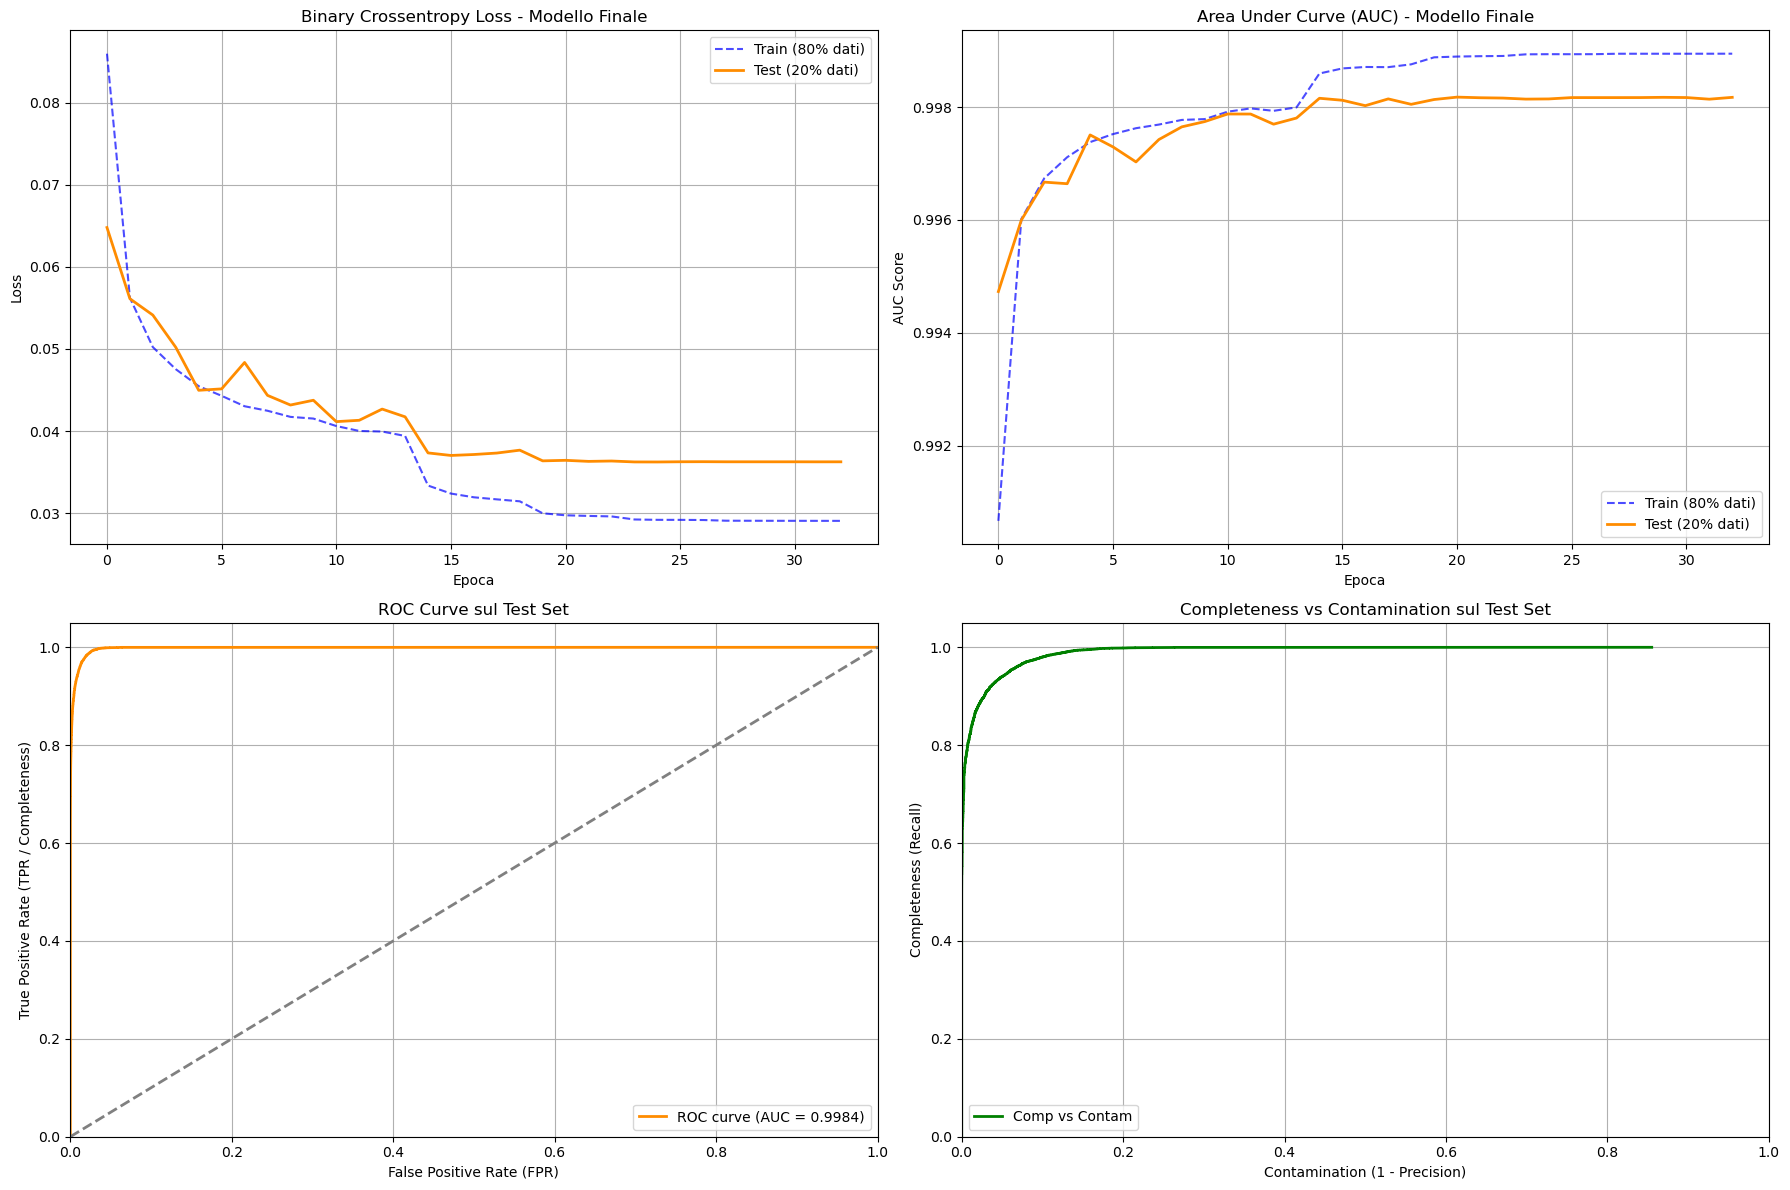

'\n# Valutazione finale numerica\nfinal_loss, final_acc, final_auc = final_model.evaluate(X_test_scaled, y_test, verbose=0)\nprint(f"\n*** PERFORMANCE ASSOLUTE SUL TEST SET INCOGNITO ***")\nprint(f" -> Accuracy: {final_acc:.4f}")\nprint(f" -> AUC:      {final_auc:.4f}")\n'

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Previsioni del modello finale sul Test Set
y_pred_probs_final = final_model.predict(X_test_scaled)

# Dati ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_probs_final)
roc_auc = auc(fpr, tpr)

# Dati Completeness e Contamination
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_probs_final)
completeness = recall
contamination = 1 - precision

# CREAZIONE GRIGLIA 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# [0, 0] Plot della Loss (in alto a sinistra)
axes[0, 0].plot(final_history.history['loss'], label='Train (80% dati)', linestyle='--', color='blue', alpha=0.7)
axes[0, 0].plot(final_history.history['val_loss'], label='Test (20% dati)', linewidth=2, color='darkorange')
axes[0, 0].set_title('Binary Crossentropy Loss - Modello Finale')
axes[0, 0].set_xlabel('Epoca')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True)

# [0, 1] Plot dell'AUC (in alto a destra)
axes[0, 1].plot(final_history.history['auc'], label='Train (80% dati)', linestyle='--', color='blue', alpha=0.7)
axes[0, 1].plot(final_history.history['val_auc'], label='Test (20% dati)', linewidth=2, color='darkorange')
axes[0, 1].set_title('Area Under Curve (AUC) - Modello Finale')
axes[0, 1].set_xlabel('Epoca')
axes[0, 1].set_ylabel('AUC Score')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True)

# [1, 0] Plot Curva ROC (in basso a sinistra)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate (FPR)')
axes[1, 0].set_ylabel('True Positive Rate (TPR / Completeness)')
axes[1, 0].set_title('ROC Curve sul Test Set')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True)

# [1, 1] Plot Completeness vs Contamination (in basso a destra)
axes[1, 1].plot(contamination, completeness, color='green', lw=2, label='Comp vs Contam')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('Contamination (1 - Precision)')
axes[1, 1].set_ylabel('Completeness (Recall)')
axes[1, 1].set_title('Completeness vs Contamination sul Test Set')
axes[1, 1].legend(loc="lower left")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

'''
# Valutazione finale numerica
final_loss, final_acc, final_auc = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n*** PERFORMANCE ASSOLUTE SUL TEST SET INCOGNITO ***")
print(f" -> Accuracy: {final_acc:.4f}")
print(f" -> AUC:      {final_auc:.4f}")
'''

In [ ]:
print("\n--- Valutazione Finale sul Test Set ---")

# Previsioni usando il modello finale addestrato sull'80% dei dati
y_pred_probs_final = final_model.predict(X_test_scaled)
y_pred_binary_final = (y_pred_probs_final > 0.5).astype(int)

# Calcolo di tutte le metriche
accuracy_final = accuracy_score(y_test, y_pred_binary_final)
completeness_final = recall_score(y_test, y_pred_binary_final)
contamination_final = 1 - precision_score(y_test, y_pred_binary_final, zero_division=0)
test_auc_final = roc_auc_score(y_test, y_pred_probs_final)
f1_final = f1_score(y_test, y_pred_binary_final)

# Recuperiamo l'accuracy massima raggiunta durante l'addestramento finale
val_acc_final = max(final_history.history['val_accuracy'])

# Stampa dei risultati
print(f"Val Accuracy Max (durante fit):   {val_acc_final:.4f}")
print(f"Accuracy Globale (Test Set):      {accuracy_final:.4f}")
print(f"AUC Score (Test Set):             {test_auc_final:.4f}")
print(f"F1-Score (Test Set):              {f1_final:.4f}")
print(f"Completeness (Recall):            {completeness_final:.4f}")
print(f"Contamination (1 - Precision):    {contamination_final:.4f}")
print()

print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred_binary_final))


--- Valutazione Finale sul Test Set ---
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 268us/step
Val Accuracy Max (durante fit):   0.9852
Accuracy Globale (Test Set):      0.9852
AUC Score (Test Set):             0.9985
F1-Score (Test Set):              0.9490
Completeness (Recall):            0.9514
Contamination (1 - Precision):    0.0533

Matrice di Confusione:
[[84700   778]
 [  706 13816]]
